# **Section 1: Dataset Overview**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/content/online_retail_II.csv')

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541910, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


**Step 1 - Check missing Values**

In [7]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


**Step 2 - Check Negative Quantity Rows**

In [8]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,01-12-2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01-12-2010 09:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,01-12-2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom


**Step 3 - Check Negative Price Rows**

In [9]:
df[df['Price'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
299983,A563186,B,Adjust bad debt,1,12-08-2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,12-08-2011 14:52,-11062.06,NaN,United Kingdom


**Step 4 - Check Duplicate Rows**

In [10]:
df.duplicated().sum()

np.int64(5268)

This dataset contains:

1. Missing customer IDs (25%)

2. Product returns

3. Accounting adjustments

4. Duplicate rows

Now we design cleaning rules.

# **Section 2 - Data Cleaning and Preparation**

Step 1 — Remove Duplicate Rows

In [11]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)


Before removing duplicates: (541910, 8)
After removing duplicates: (536642, 8)


Step 2 — Remove Invalid Price Rows

In [12]:
print("Rows with Price <= 0:", df[df["Price"] <= 0].shape)

df = df[df["Price"] > 0]

print("After removing invalid price rows:", df.shape)


Rows with Price <= 0: (2512, 8)
After removing invalid price rows: (534130, 8)


Step 3 — Keep Returns (Negative Quantity)

We chose to keep negative quantities in the dataset because they represent product returns, which are an important part of capturing realistic business performance. Since revenue is calculated as `Quantity × Price`, a negative quantity produces negative revenue, effectively recording returns. This approach ensures that our revenue figures reflect **net revenue** (sales minus returns) rather than just gross sales, giving a more accurate financial picture.

Step 4 — Convert InvoiceDate to Datetime

In [13]:

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 534130 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      534130 non-null  object        
 1   StockCode    534130 non-null  object        
 2   Description  534130 non-null  object        
 3   Quantity     534130 non-null  int64         
 4   InvoiceDate  534130 non-null  datetime64[ns]
 5   Price        534130 non-null  float64       
 6   Customer ID  401565 non-null  float64       
 7   Country      534130 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.7+ MB


Step 5 — Create Revenue Column

In [14]:
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# **Section 3 — Revenue Overview & Business Metrics**

Step 1 — Basic Revenue Metrics

In [15]:
total_revenue = df["Revenue"].sum()
total_transactions = df["Invoice"].nunique()
total_products_sold = df[df["Quantity"] > 0]["Quantity"].sum()
total_returns = df[df["Quantity"] < 0]["Revenue"].sum()

print("BUSINESS OVERVIEW METRICS")
print("-------------------------")
print(f"Total Revenue (Net): {total_revenue:,.2f}")
print(f"Total Unique Transactions: {total_transactions}")
print(f"Total Products Sold (Units): {total_products_sold}")
print(f"Total Revenue Lost from Returns: {total_returns:,.2f}")


BUSINESS OVERVIEW METRICS
-------------------------
Total Revenue (Net): 9,748,149.07
Total Unique Transactions: 23796
Total Products Sold (Units): 5572421
Total Revenue Lost from Returns: -893,979.73


Step 2 — Finding Average Order Value

In [16]:
avg_order_value = total_revenue / total_transactions
print(f"Average Revenue per Transaction: {avg_order_value:,.2f}")


Average Revenue per Transaction: 409.65


Step 3 — Finding Average Units per Transaction

In [17]:
avg_units_per_order = total_products_sold / total_transactions
print(f"Average Units per Transaction: {avg_units_per_order:,.2f}")


Average Units per Transaction: 234.17


Step 4 — Finding Return Impact Percentage

In [18]:
return_impact = abs(total_returns) / total_revenue * 100
print(f"Return Impact on Revenue: {return_impact:.2f}%")


Return Impact on Revenue: 9.17%


The business:

* Generates ~9.75M net revenue

* Processes ~23.8K transactions

* Sells ~5.57M units

* Loses ~894K from returns

# **Section 4 — Monthly Revenue Trend Analysis**

Step 1 — Extract Year and Month

In [19]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12


Step 2 — Create Year-Month Column (For Clean Grouping)

In [20]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")


Step 3 — Monthly Revenue Aggregation

In [21]:
monthly_revenue = df.groupby("YearMonth")["Revenue"].sum()

monthly_revenue.head()


,Revenue
YearMonth,
2010-12,746723.610
2011-01,558448.560
2011-02,497026.410
2011-03,682013.980
2011-04,492367.841


Step 4 — Plot Monthly Revenue

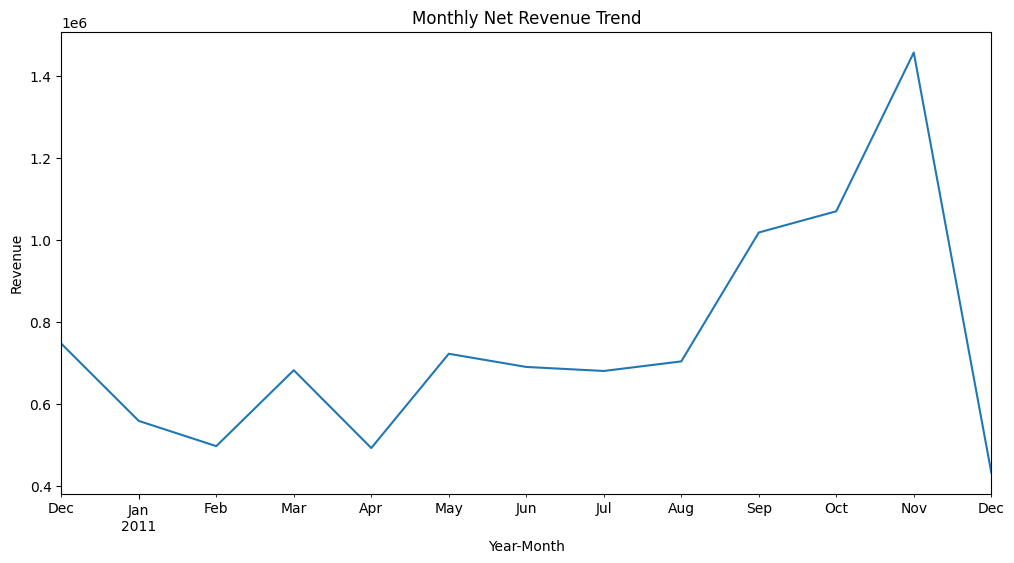

In [22]:
monthly_revenue.plot(figsize=(12,6))

plt.title("Monthly Net Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.show()


In [23]:
df["InvoiceDate"].max()


Timestamp('2011-12-09 12:50:00')

**1️. Revenue Pattern Overview**

Monthly revenue shows moderate stability during the early and mid-year period, followed by a strong acceleration beginning in late Q3 and peaking in Q4.

Revenue gradually increases from August onward and reaches its highest point in November.

This indicates clear seasonal strengthening toward the end of the year.

**2️. Q4 Acceleration**

The strongest revenue growth occurs between September and November.

This pattern is consistent with seasonal retail behavior, where year-end purchasing activity increases significantly due to holiday-driven demand and bulk orders.

The November peak suggests that the business experiences its highest transactional intensity during this period.

**3️. December Drop Interpretation**

Although revenue drops sharply in December, the dataset only includes data up to December 9, 2011.

Therefore, this decline does not represent actual business slowdown but rather incomplete month data.

This demonstrates the importance of validating data completeness before interpreting trends.

**4️. Business Implications**

The company demonstrates strong seasonality.

Q4 is the most critical revenue period.

Inventory planning, marketing campaigns, and logistics capacity should be optimized ahead of Q4 demand spikes.

Operational readiness before October is strategically important.

# **Section 5 — Country-Level Revenue Analysis**

**5.1 Revenue Aggregation by Country**

In [24]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

country_revenue.head(10)


,Revenue
Country,
United Kingdom,8189252.304
Netherlands,284661.540
EIRE,262993.380
Germany,221509.470
France,197335.110
Australia,137009.770
Switzerland,56363.050
Spain,54756.030
Belgium,40910.960


In [25]:
country_share = (country_revenue / total_revenue) * 100
country_share.head(10)


,Revenue
Country,
United Kingdom,84.008279
Netherlands,2.920160
EIRE,2.697880
Germany,2.272323
France,2.024334
Australia,1.405495
Switzerland,0.578192
Spain,0.561707
Belgium,0.419679


**5.2 Revenue Concentration Insight**

**Strategic Risk**

* Business is highly exposed to UK economic conditions.

* Any regulatory, currency, or demand shock in UK could severely impact revenue.

* International expansion is weak.

**Strategic Opportunity**

* Netherlands, Germany, and France show early traction.

* These could be scaled further through targeted marketing.

* Geographic diversification could reduce revenue concentration risk.

**5.3 Country-Level Revenue Visualization**

Plot including UK

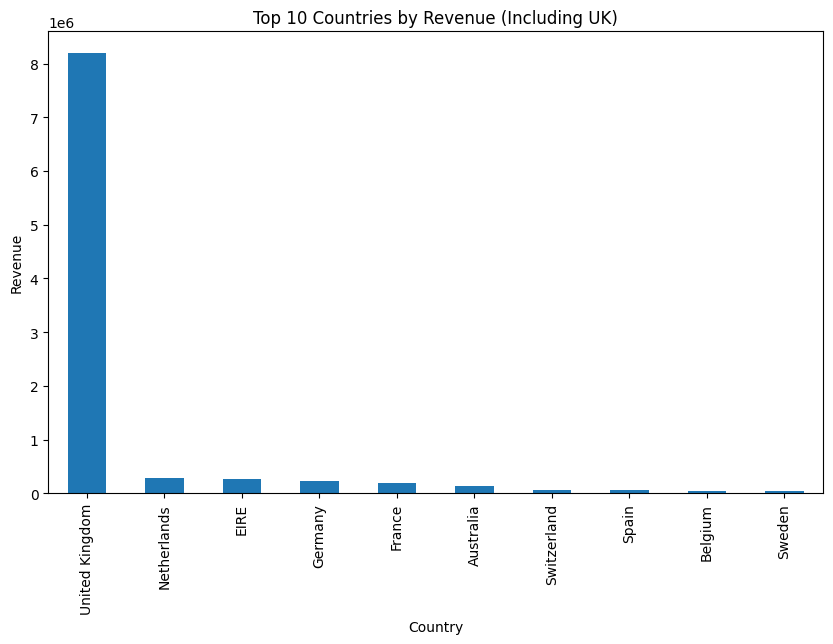

In [26]:
country_revenue.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Countries by Revenue (Including UK)")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()


Plot Excluding UK

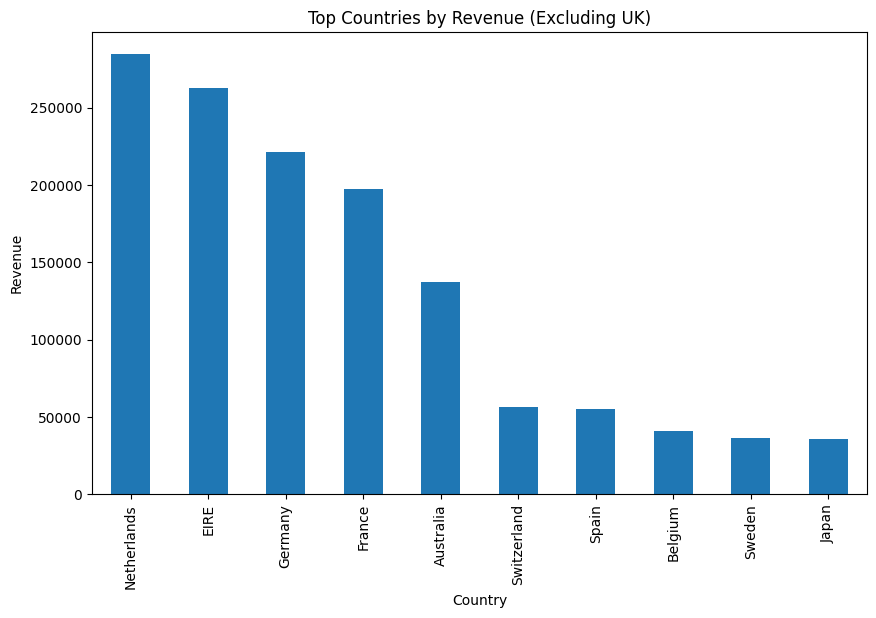

In [27]:
country_ex_uk = country_revenue.drop("United Kingdom")

country_ex_uk.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top Countries by Revenue (Excluding UK)")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()


The company exhibits:

* Extreme dependency on UK (84%)

* Moderate international diversification among top 4–5 countries

* Sharp decline in revenue contribution beyond mid-tier markets

Implication:

International revenue is present but shallow beyond the top few countries.

# **Section 6 — Product-Level Revenue Drivers**

**6.1 Revenue by Product**

In [28]:
product_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
product_revenue.head(10)


,Revenue
Description,
DOTCOM POSTAGE,206245.48
REGENCY CAKESTAND 3 TIER,164459.49
WHITE HANGING HEART T-LIGHT HOLDER,99612.42
PARTY BUNTING,98243.88
JUMBO BAG RED RETROSPOT,92175.79
RABBIT NIGHT LIGHT,66661.63
POSTAGE,66248.64
PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
ASSORTED COLOUR BIRD ORNAMENT,58792.42


**6.2 Quantity Sold by Product**

In [29]:
product_quantity = df[df['Quantity'] > 0].groupby('Description')['Quantity'].sum().sort_values(ascending=False)
product_quantity.head(10)


,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


**6.3 Refinement: Excluding Operational Charges**

During initial revenue ranking, the top-performing item was identified as **DOTCOM POSTAGE**, followed by **POSTAGE** appearing within the top revenue contributors.

However, these entries do not represent actual merchandise. They are operational charges related to shipping and logistics.

Including them in product performance analysis would distort interpretation for three key reasons:

1. Shipping charges are service-related revenue, not product demand.

2. Their revenue contribution does not reflect consumer preference or product popularity.

3. They artificially inflate the ranking, potentially masking high-performing merchandise.

Since the objective of this section is to evaluate product-level performance, operational revenue items must be excluded to ensure analytical accuracy.

Removing postage-related entries allows us to:

* Identify true top-selling products.

* Understand customer purchasing behavior.

* Distinguish between revenue driven by merchandise versus logistics.

This ensures the analysis reflects product strategy rather than operational billing.

Step 1 — Remove Postage-Related Entries

In [30]:
df_products = df[~df["Description"].str.contains("POSTAGE", case=False, na=False)]


Step 2 — Recalculate Product Revenue

In [31]:
product_revenue_clean = df_products.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
product_revenue_clean.head(10)

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,164459.49
WHITE HANGING HEART T-LIGHT HOLDER,99612.42
PARTY BUNTING,98243.88
JUMBO BAG RED RETROSPOT,92175.79
RABBIT NIGHT LIGHT,66661.63
PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
ASSORTED COLOUR BIRD ORNAMENT,58792.42
CHILLI LIGHTS,53746.66
SPOTTY BUNTING,42030.67


Step 3 — Recalculate Quantity Ranking

In [38]:
product_quantity_clean = df_products[df_products['Quantity'] > 0].groupby('Description')['Quantity'].sum().sort_values(ascending = False)
product_quantity_clean.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


After removing operational items like postage, we identified true merchandise performance. “REGENCY CAKESTAND 3 TIER” emerged as the top product by revenue, while products like “PAPER CRAFT, LITTLE BIRDIE” sell in high volume but contribute less to revenue individually. Some products, like “JUMBO BAG RED RETROSPOT,” performed strongly on both revenue and quantity metrics, making them strategic products for growth. This section helped distinguish between volume drivers, high-revenue items, and true core products, giving a nuanced view of merchandise performance.

# **Section 7 — Revenue Distribution & Customer Segmentation**

**7.1 — Revenue Distribution Analysis (Pareto)**

Step 1 — Total Revenue per Customer

In [33]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue.head()

,Revenue
Customer ID,
14646.0,279489.02
18102.0,256438.49
17450.0,187322.17
14911.0,132458.73
12415.0,123725.45


Step 2 — Cumulative Revenue Share

In [34]:
cum_revenue = customer_revenue.cumsum()
total_rev = customer_revenue.sum()

cum_pct = cum_revenue / total_rev * 100

cum_pct.head()


,Revenue
Customer ID,
14646.0,3.376068
18102.0,6.473698
17450.0,8.736443
14911.0,10.336468
12415.0,11.831001


Step 3 — Plot Cumulative Revenue Share

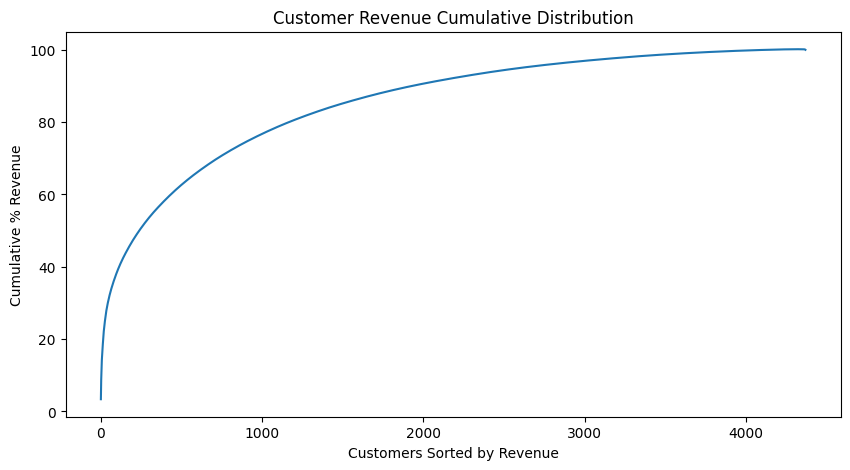

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(cum_pct.values)
plt.title("Customer Revenue Cumulative Distribution")
plt.xlabel("Customers Sorted by Revenue")
plt.ylabel("Cumulative % Revenue")
plt.show()


**7.2 — Customer Segmentation**

Step 1 — Create RFM-style Metrics

In [36]:
customer_freq = df.groupby("Customer ID")["Invoice"].nunique()
customer_monetary = df.groupby("Customer ID")["Revenue"].sum()

customer_summary = pd.DataFrame({
    "Frequency": customer_freq,
    "Monetary": customer_monetary
})

customer_summary.head()


,Frequency,Monetary
Customer ID,,
12346.0,2,0.00
12347.0,7,4310.00
12348.0,4,1797.24
12349.0,1,1757.55
12350.0,1,334.40


Step 3 — Identify Top Customers

In [37]:
top_customers = customer_summary.sort_values(by="Monetary", ascending=False).head(10)
top_customers


,Frequency,Monetary
Customer ID,,
14646.0,76,279489.02
18102.0,62,256438.49
17450.0,55,187322.17
14911.0,248,132458.73
12415.0,26,123725.45
14156.0,66,113214.59
17511.0,46,88125.38
16684.0,31,65892.08
13694.0,60,62690.54


The revenue distribution across customers exhibits strong concentration: a small number of customers contribute a disproportionate share of total revenue, as shown in the Pareto cumulative revenue distribution. For instance, Customer 14646 and 18102 together generate over half a million in net revenue. These high-value customers also exhibit high transaction frequency, indicating strong loyalty or bulk purchasing behavior. Conversely, the majority of customers have few transactions and generate minimal revenue, forming the long tail of the customer base. This suggests that targeted retention and loyalty programs for high-value customers could significantly stabilize and grow overall revenue, while promotional efforts for the long tail might focus on increasing purchase frequency and basket size.

# **Section 8 — Strategic Insights & Recommendations**

**Strategic Insights**

1. **Revenue concentration is high among a small set of customers.**
   The Pareto analysis shows that a limited subset of customers contributes the majority of revenue, indicating that customer retention strategies can have outsized impact.

2. **High-value customers exhibit both high frequency and high revenue.**
   Customers like 14646 and 18102 not only spend large amounts but also transact frequently, making them prime candidates for loyalty programs and premium services.

3. **The customer base has a long tail of low-revenue, infrequent buyers.**
   While many customers generate minimal revenue individually, collectively they form a base that could be nurtured to increase purchase frequency.

4. **Core products align with customer demand.**
   Top merchandise items such as REGENCY CAKESTAND 3 TIER and JUMBO BAG RED RETROSPOT are both revenue and volume drivers, suggesting strong product-market fit.

5. **Geographic concentration presents both risk and opportunity.**
   With 84% of revenue from the United Kingdom, there is strong home market dominance, but also a strategic need for international diversification.

**Strategic Recommendations**

1. Prioritize high-value customers with personalized loyalty programs, dedicated support, and exclusive offers to reduce churn and increase lifetime value.

2. Leverage top products for bundles and promotions to encourage cross-selling and higher basket size.

3. Explore international expansion strategies focused on secondary markets such as Netherlands, EIRE, Germany, and France to diversify revenue sources.

4. Implement targeted marketing campaigns aimed at mid-tier and long-tail customers to increase purchase frequency and shift them upward in revenue contribution.
